In [5]:
import pandas as pd

news_df = pd.read_csv("../data/raw/raw_analyst_ratings.csv")

In [7]:
stock_df = pd.read_csv("../data/raw/AAPL.csv")

Clean & Prepare Dates

In [8]:
news_df["date"] = pd.to_datetime(
    news_df["date"],
    format="mixed",
    utc=True
)

news_df["date"] = news_df["date"].dt.date

In [9]:
stock_df["Date"] = pd.to_datetime(stock_df["Date"])

stock_df["Date"] = stock_df["Date"].dt.date

In [10]:
trading_days = set(stock_df["Date"])

In [11]:
from datetime import timedelta

def align_to_trading_day(date):
    while date not in trading_days:
        date = date + timedelta(days=1)
    return date

In [12]:
news_df["aligned_date"] = news_df["date"].apply(
    align_to_trading_day
)

Sentiment Analysis


In [13]:
pip install vaderSentiment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 215.9 kB/s eta 0:00:00a 0:00:01

[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [14]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

news_df["sentiment_score"] = news_df["headline"].apply(
    lambda x: analyzer.polarity_scores(str(x))["compound"]
)

Aggregate Daily Sentiment

In [15]:
daily_sentiment = (
    news_df.groupby("aligned_date")["sentiment_score"]
    .mean()
    .reset_index()
)

In [16]:
stock_df["daily_return"] = (
    stock_df["Close"].pct_change() * 100
)

In [17]:
merged_df = pd.merge(
    daily_sentiment,
    stock_df,
    left_on="aligned_date",
    right_on="Date",
    how="inner"
)

In [18]:
correlation = merged_df["sentiment_score"].corr(
    merged_df["daily_return"]
)

print("Pearson Correlation:", correlation)

Pearson Correlation: 0.1412720436024394


Scatter Plot

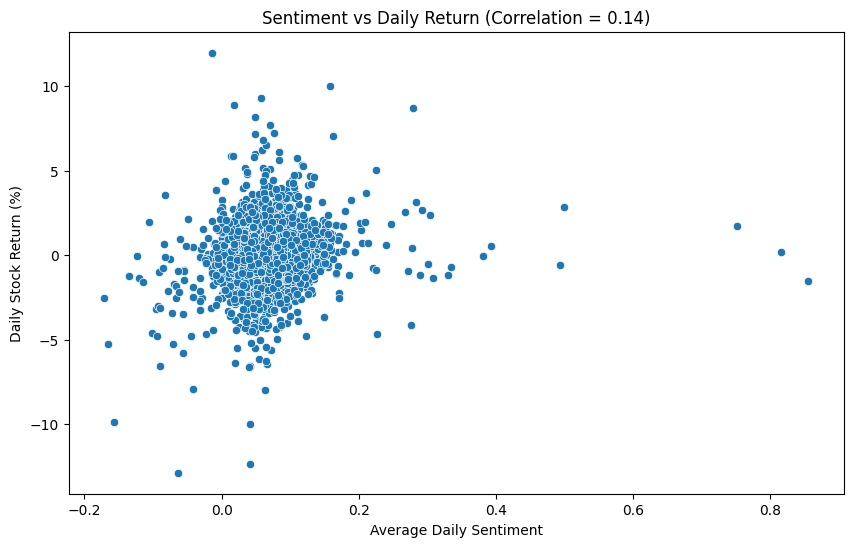

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=merged_df,
    x="sentiment_score",
    y="daily_return"
)

plt.title(
    f"Sentiment vs Daily Return (Correlation = {correlation:.2f})"
)

plt.xlabel("Average Daily Sentiment")
plt.ylabel("Daily Stock Return (%)")

plt.show()

Sentiment Classification

In [21]:
def classify_sentiment(score):
    if score > 0.05:
        return "Positive"
    elif score < -0.05:
        return "Negative"
    else:
        return "Neutral"

In [22]:
merged_df["sentiment_category"] = (
    merged_df["sentiment_score"]
    .apply(classify_sentiment)
)

Average Return Per Category

In [23]:
category_returns = (
    merged_df.groupby("sentiment_category")["daily_return"]
    .mean()
    .reset_index()
)

Bar Chart

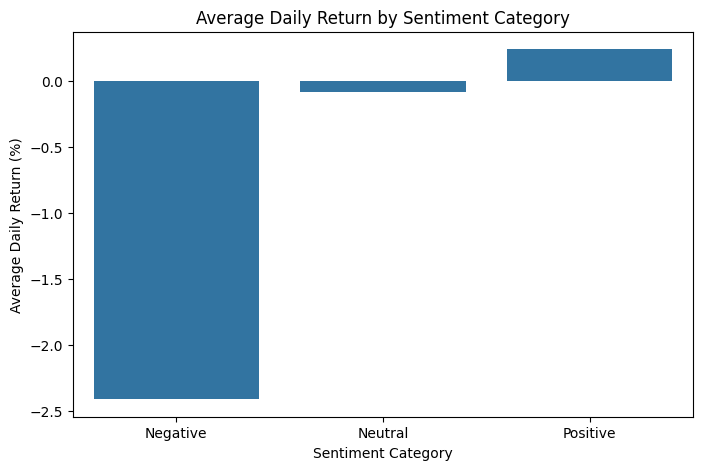

In [24]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=category_returns,
    x="sentiment_category",
    y="daily_return"
)

plt.title("Average Daily Return by Sentiment Category")

plt.xlabel("Sentiment Category")
plt.ylabel("Average Daily Return (%)")

plt.show()

The correlation between sentiment and daily stock returns was weakly positive, suggesting that positive financial news may have a limited relationship with short-term stock performance. However, market movement is influenced by many external factors, including macroeconomic conditions, earnings announcements, and investor behavior.